<a href="https://colab.research.google.com/github/Prakriti1103/DNN-vs-CNN-vs-CNN-Augmentation-Cifar-10-Classification/blob/main/DNN_Cifar10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Statement CIFAR-10 is a dataset that consists of several images divided into the following 10 classes:

Aeroplane

Cars

Birds

Cats

Deer

Dogs

Frogs

Horses

Ships

Trucks

The dataset stands for the Canadian Institute For Advanced Research(CIFAR).

CIFAR-10 is widely used for machine learning and computer vision applications.

The dataset consists of 60,000 32X32 color images and 6,000 images of each class.

Images have low resolution (32X32).

Data Sources : https://www.cs.toronto.edu/~kriz/cifar.html

Import Libraries and dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 202s 1us/step


In [ ]:
X_train.shape

(50000, 32, 32, 3)

In [ ]:
X_test.shape

(10000, 32, 32, 3)

In [ ]:
y_train.shape

(50000, 1)

In [ ]:
y_test.shape

(10000, 1)

Data Visualization

[8]


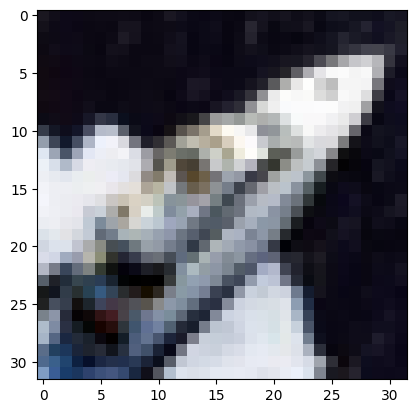

In [ ]:
i = 20000
plt.imshow(X_train[i])
print(y_train[i])

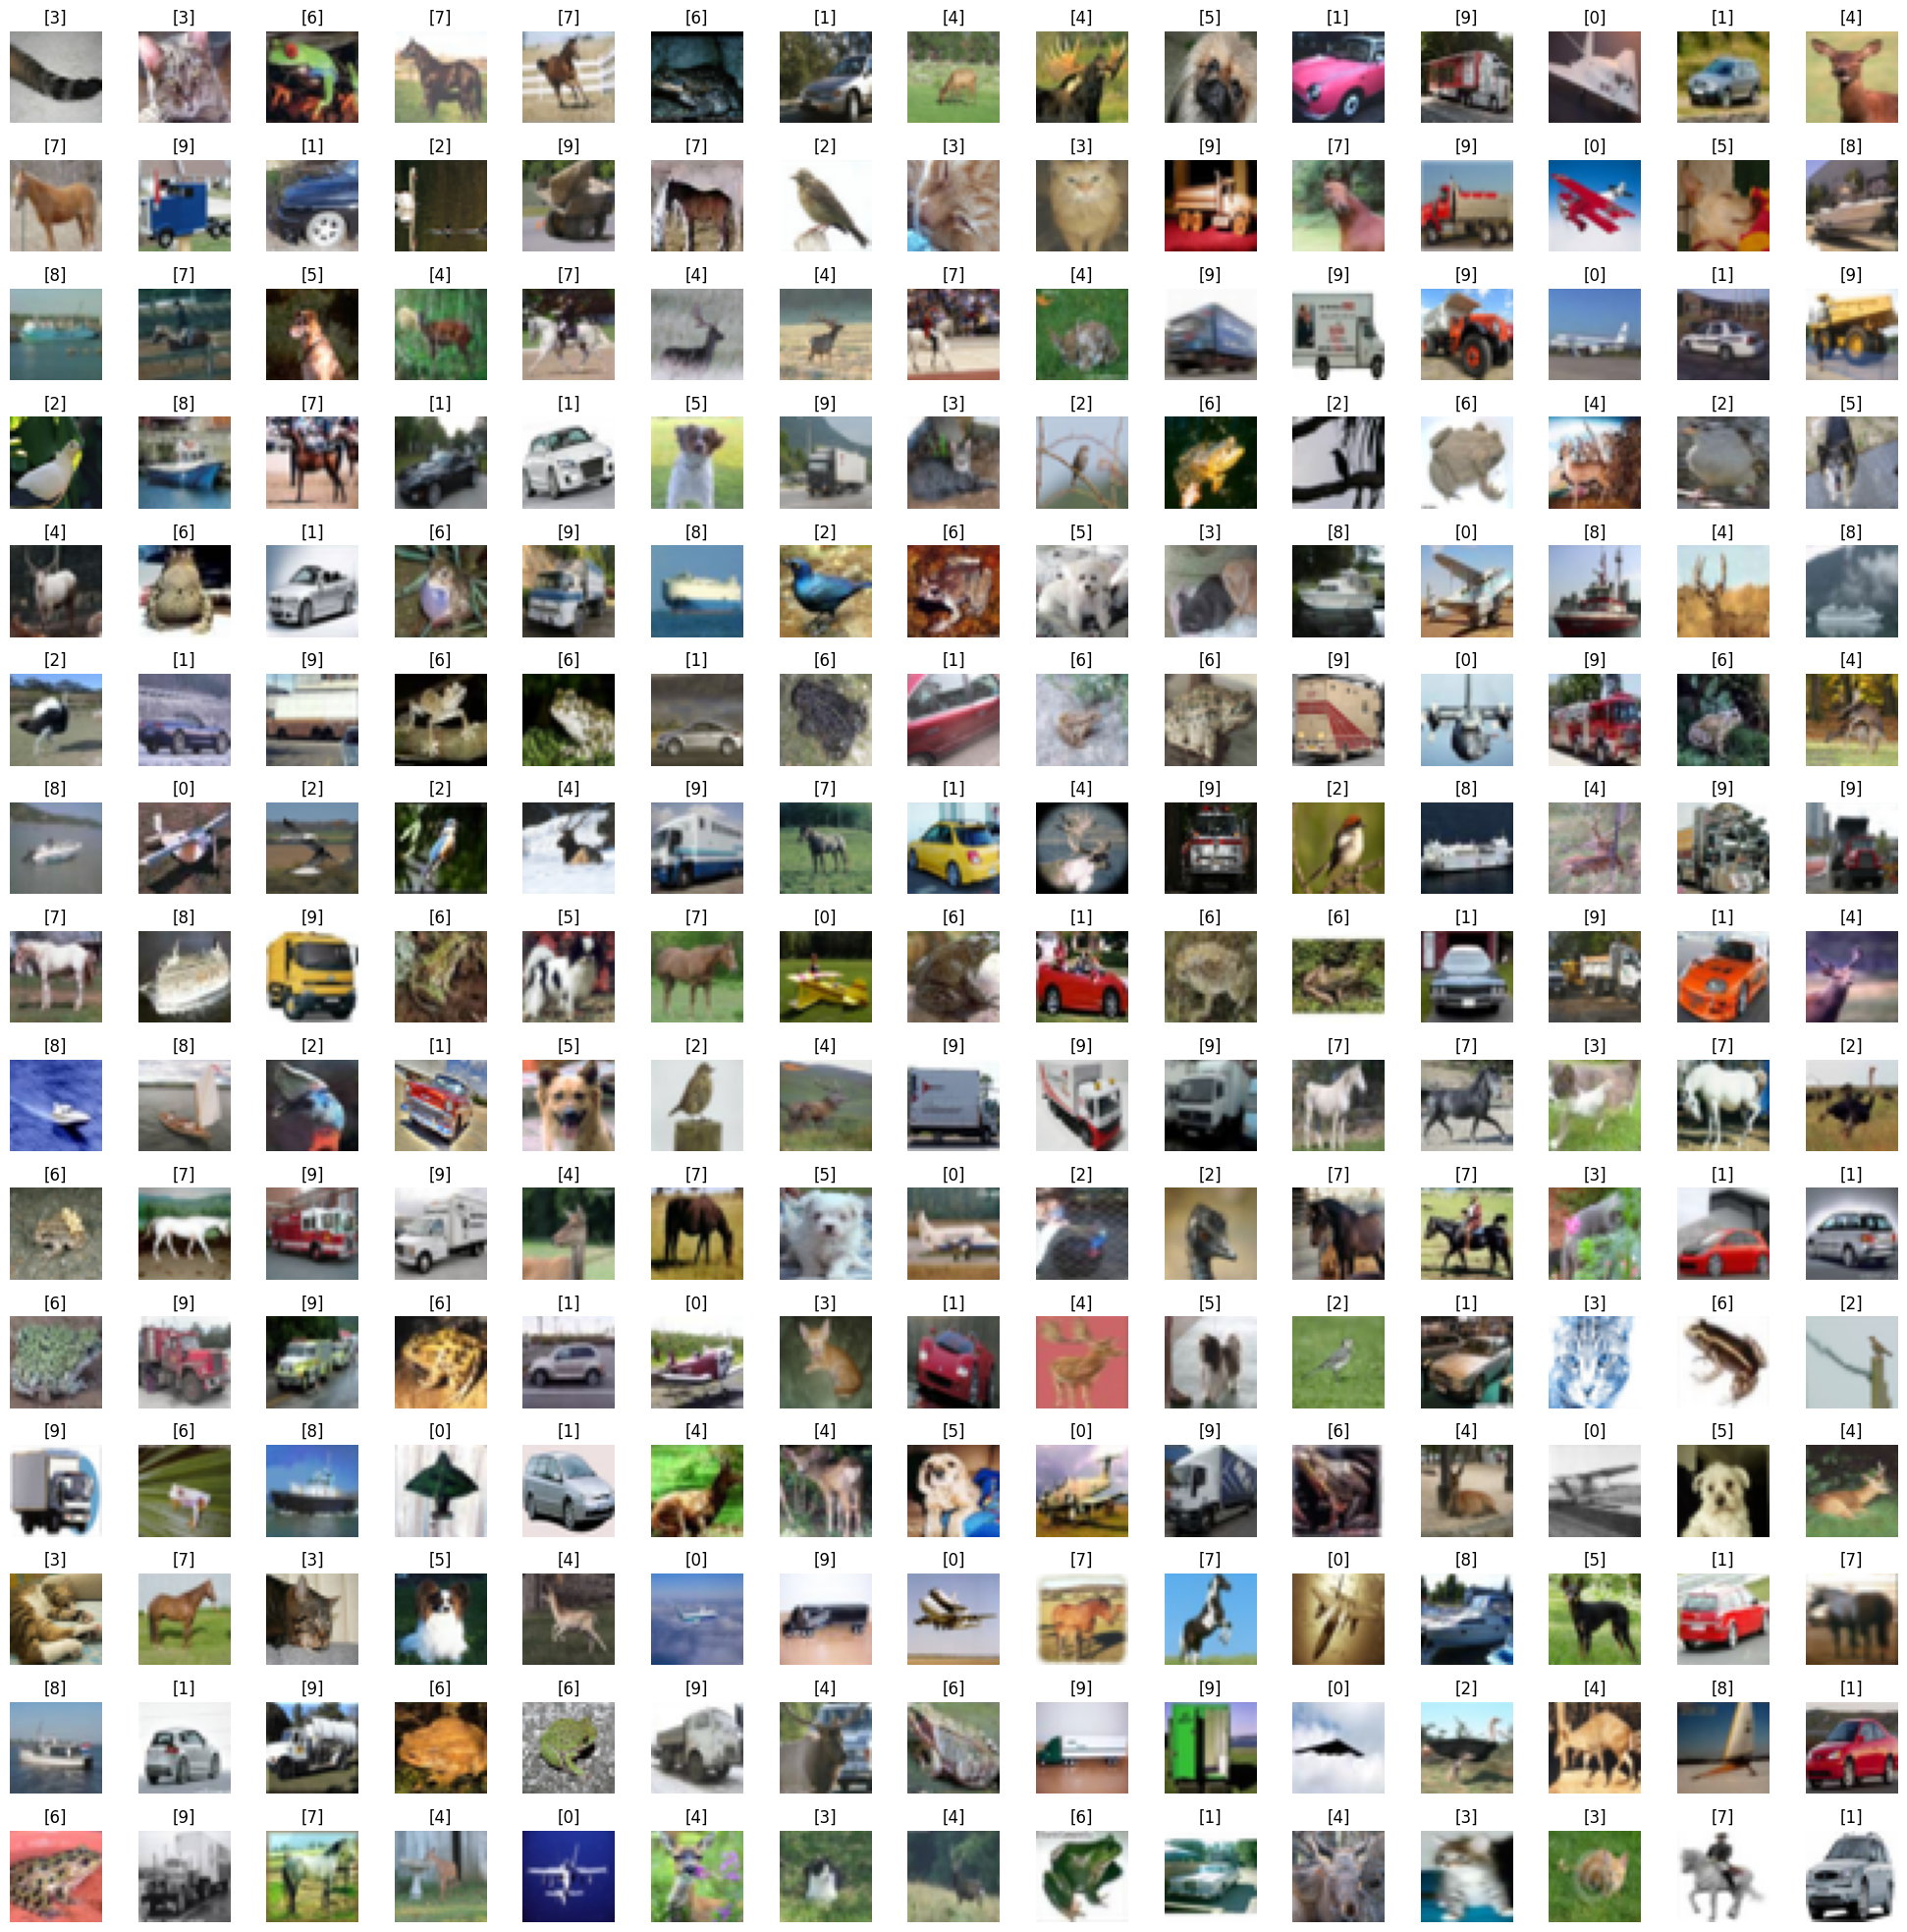

In [ ]:
W_grid = 15
L_grid = 15

fig, axes = plt.subplots(L_grid, W_grid, figsize = (25,25))
axes =  axes.ravel()

n_training = len(X_train)

for i in np.arange(0, L_grid * W_grid):
  index = np.random.randint(0, n_training)
  axes[i].imshow(X_train[index])
  axes[i].set_title(y_train[index])
  axes[i].axis('off')

plt.subplots_adjust(hspace = 0.4)

In [ ]:
n_training

50000

Data Preparation

In [ ]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')


In [ ]:
number_cat = 10

In [ ]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [ ]:
import keras
y_train = keras.utils.to_categorical(y_train, number_cat)
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [ ]:
X_train = X_train/255
X_test = X_test/255
X_train

array([[[[0.23137255, 0.24313726, 0.24705882],
         [0.16862746, 0.18039216, 0.1764706 ],
         [0.19607843, 0.1882353 , 0.16862746],
         ...,
         [0.61960787, 0.5176471 , 0.42352942],
         [0.59607846, 0.49019608, 0.4       ],
         [0.5803922 , 0.4862745 , 0.40392157]],

        [[0.0627451 , 0.07843138, 0.07843138],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509805, 0.21568628],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117648, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215687, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941177, 0.19607843],
         [0.47058824, 0.32941177, 0.19607843],
         [0.42745098, 0.28627452, 0.16470589]],

        ...,

        [[0.8156863 , 0.6666667 , 0.3764706 ],
         [0.7882353 , 0.6       , 0.13333334]

Splitting Data for Validation

We'll split the X_train and y_train into training and validation sets to monitor model performance on unseen data during training.

In [ ]:
from sklearn.model_selection import train_test_split

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"X_train_split shape: {X_train_split.shape}")
print(f"y_train_split shape: {y_train_split.shape}")
print(f"X_val_split shape: {X_val_split.shape}")
print(f"y_val_split shape: {y_val_split.shape}")

X_train_split shape: (40000, 32, 32, 3)
y_train_split shape: (40000, 10)
X_val_split shape: (10000, 32, 32, 3)
y_val_split shape: (10000, 10)


In [ ]:
X_train.shape

(50000, 32, 32, 3)

In [ ]:
Input_shape = X_train.shape[1:]
Input_shape

(32, 32, 3)

Train the Model

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, BatchNormalization

dnn_model = Sequential()

# Input → Flatten
dnn_model.add(Flatten(input_shape=Input_shape))

# Hidden Layer 1
dnn_model.add(Dense(512, activation='relu'))
dnn_model.add(BatchNormalization())
dnn_model.add(Dropout(0.5))

# Hidden Layer 2
dnn_model.add(Dense(256, activation='relu'))
dnn_model.add(BatchNormalization())
dnn_model.add(Dropout(0.5))

# Hidden Layer 3
dnn_model.add(Dense(128, activation='relu'))
dnn_model.add(BatchNormalization())
dnn_model.add(Dropout(0.5))

# Output Layer
dnn_model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile
dnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Train (Important part)
history_dnn = dnn_model.fit(
    X_train_split, y_train_split,
    batch_size=64,
    epochs=30,
    validation_data=(X_val_split, y_val_split),
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.2446 - loss: 2.2808 - val_accuracy: 0.3354 - val_loss: 1.8523
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.3192 - loss: 1.8781 - val_accuracy: 0.3249 - val_loss: 1.8283
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3402 - loss: 1.8296 - val_accuracy: 0.3382 - val_loss: 1.7860
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.3513 - loss: 1.8066 - val_accuracy: 0.3604 - val_loss: 1.7704
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.3486 - loss: 1.8082 - val_accuracy: 0.3922 - val_loss: 1.6886
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3541 - loss: 1.7969 - val_accuracy: 0.3805 - val_loss: 1.7040
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.3603 - loss: 1.7854 - val_accuracy: 0.3688 - val_loss: 1.7609
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3668 - loss: 1.7708 - 

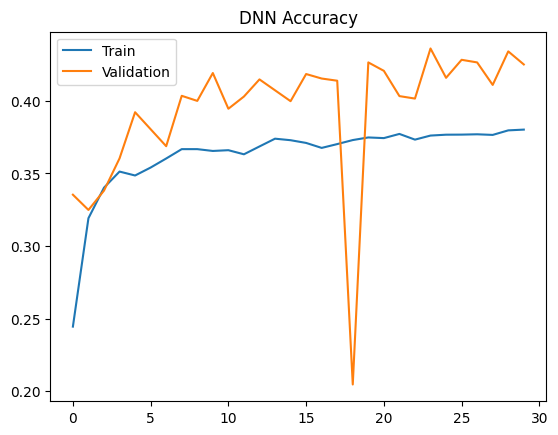

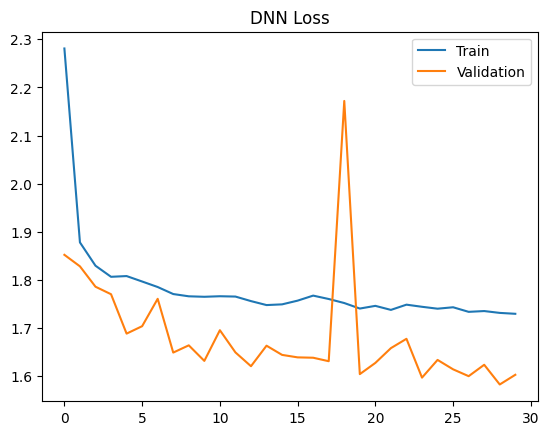

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history_dnn.history['accuracy'])
plt.plot(history_dnn.history['val_accuracy'])
plt.title('DNN Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history_dnn.history['loss'])
plt.plot(history_dnn.history['val_loss'])
plt.title('DNN Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
import keras
y_test = keras.utils.to_categorical(y_test, number_cat)
#Evaluate
dnn_eval = dnn_model.evaluate(X_test, y_test)
print("DNN Test Accuracy:", dnn_eval[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4332 - loss: 1.5834
DNN Test Accuracy: 0.43320000171661377


In [ ]:
#Predicitions
y_pred_dnn = dnn_model.predict(X_test)
y_pred_classes_dnn = y_pred_dnn.argmax(axis=1)

y_test_labels = y_test.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
